# Phase 4: Exploratory Data Analysis

Demographics, risk-factor distributions, discomfort prevalence. Figures saved to outputs/figures/.

## Step 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')

CWD = Path.cwd()
ROOT = CWD if (CWD / 'data').exists() else CWD.parent
df   = pd.read_csv(ROOT / 'data' / 'processed' / 'model_ready.csv')
risk = pd.read_csv(ROOT / 'data' / 'processed' / 'risk_profile.csv')
FIGS = ROOT / 'outputs' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

print('model_ready :', df.shape)
print('risk_profile:', risk.shape)

model_ready : (182, 67)
risk_profile: (182, 14)


## Step 1 — Quick overview

In [2]:
assert len(df) == len(risk) == 182

risk_cols = ['force_risk', 'repetition_risk', 'duration_risk',
             'vibration_risk', 'contact_stress_risk', 'posture_risk']
{c: risk[c].value_counts().to_dict() for c in risk_cols}

{'force_risk': {'Low': 90, 'Medium': 57, 'High': 35},
 'repetition_risk': {'Medium': 84, 'Low': 79, 'High': 19},
 'duration_risk': {'High': 89, 'Medium': 56, 'Low': 37},
 'vibration_risk': {'Medium': 68, 'Low': 67, 'High': 47},
 'contact_stress_risk': {'Low': 68, 'Medium': 58, 'High': 56},
 'posture_risk': {'Not Assessed': 182}}

## Step 2 — Demographics

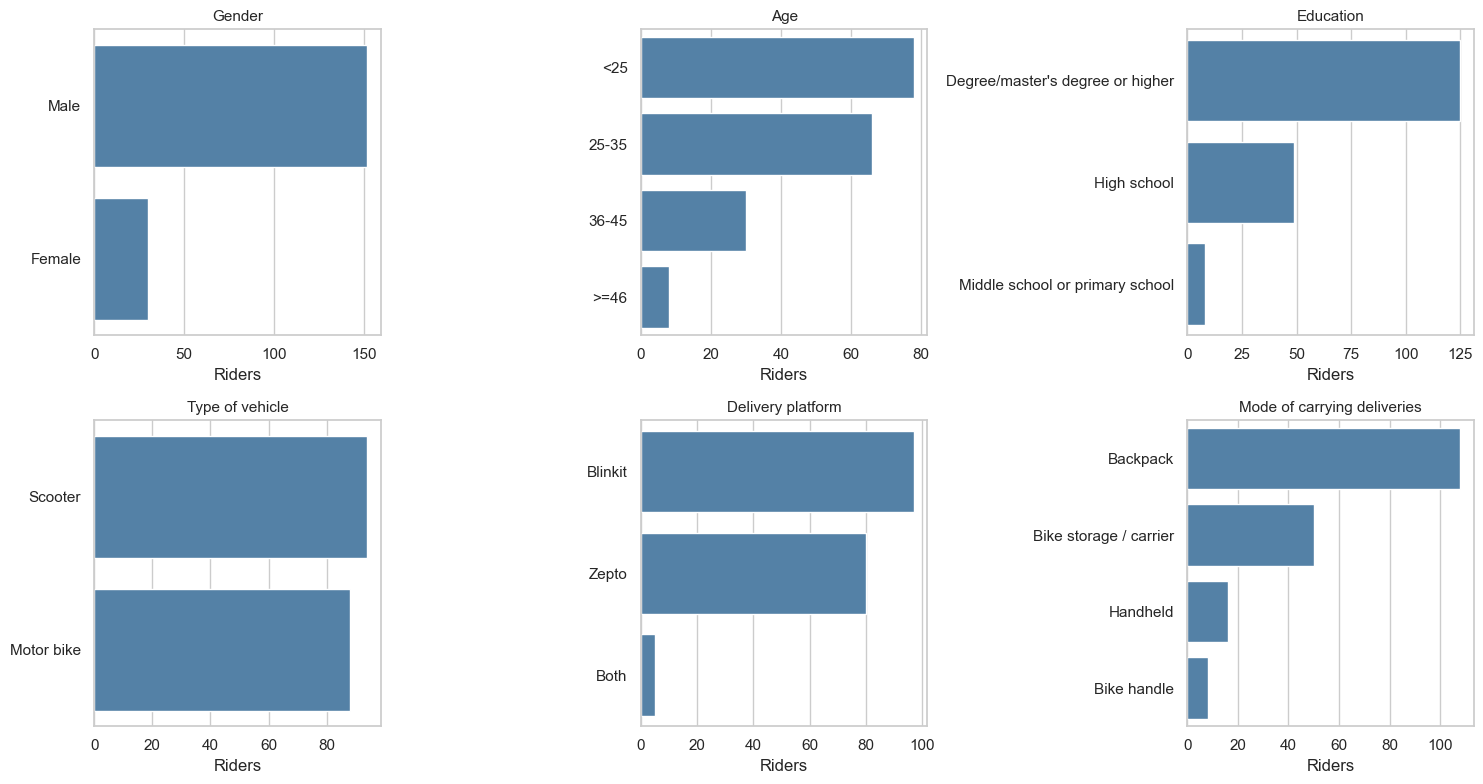

In [3]:
demo_cols = ['Gender', 'Age', 'Education',
             'Type of vehicle', 'Delivery platform', 'Mode of carrying deliveries']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, demo_cols):
    vc = df[c].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax, color='steelblue')
    ax.set_title(c, fontsize=11)
    ax.set_xlabel('Riders')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGS / 'demographics.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3 — Risk factor distribution

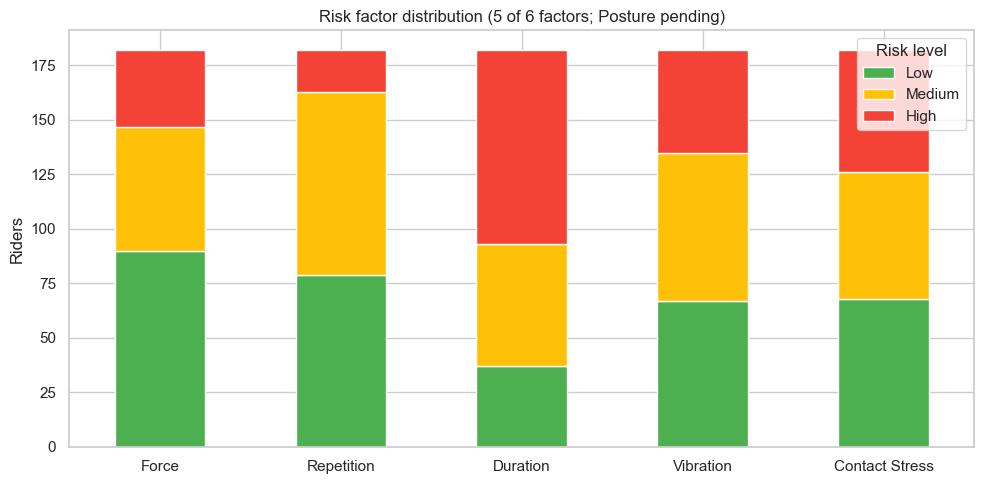

,Force,Repetition,Duration,Vibration,Contact Stress
Low,90,79,37,67,68
Medium,57,84,56,68,58
High,35,19,89,47,56


In [4]:
risk_factors = ['force_risk', 'repetition_risk', 'duration_risk',
                'vibration_risk', 'contact_stress_risk']
order = ['Low', 'Medium', 'High']

counts = pd.DataFrame({f: risk[f].value_counts() for f in risk_factors}).reindex(order).fillna(0).astype(int)
counts.columns = ['Force', 'Repetition', 'Duration', 'Vibration', 'Contact Stress']

fig, ax = plt.subplots(figsize=(10, 5))
counts.T.plot(kind='bar', stacked=True, ax=ax,
              color=['#4CAF50', '#FFC107', '#F44336'])
ax.set_ylabel('Riders')
ax.set_title('Risk factor distribution (5 of 6 factors; Posture pending)')
ax.legend(title='Risk level')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGS / 'risk_factor_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
counts

## Step 4 — Discomfort prevalence by body area (Nordic 12-month)

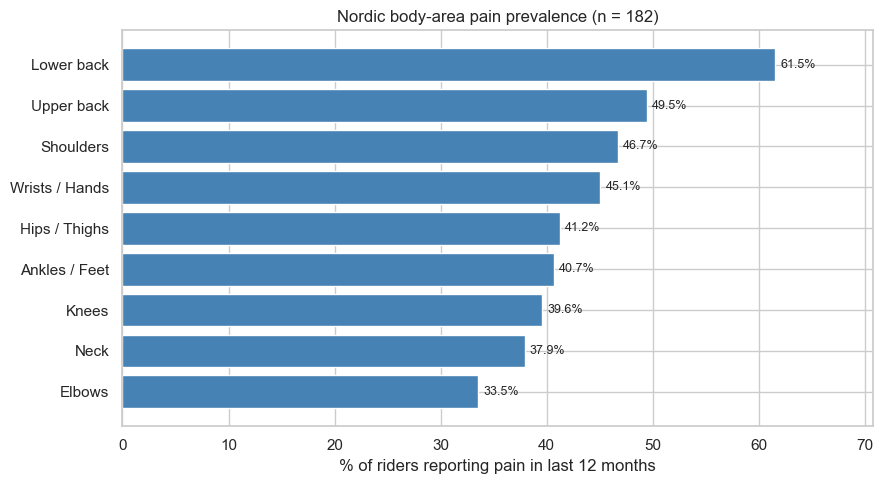

Overall discomfort prevalence (any body area): 84.6 %

Per-area prevalence (sorted, %):
Lower back        61.5
Upper back        49.5
Shoulders         46.7
Wrists / Hands    45.1
Hips / Thighs     41.2
Ankles / Feet     40.7
Knees             39.6
Neck              37.9
Elbows            33.5


In [5]:
# 9 Nordic body-area items, already 1/0 after Phase 2
nordic_cols = [c for c in df.columns if 'In the past 12 months' in c]

prev = df[nordic_cols].mean() * 100
# Strip the long survey header to just the body-area label
prev.index = [c.split('[')[-1].rstrip(']').replace('Row 1', '') for c in nordic_cols]
prev = prev.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(prev.index, prev.values, color='steelblue')
for bar, val in zip(bars, prev.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% of riders reporting pain in last 12 months')
ax.set_title('Nordic body-area pain prevalence (n = 182)')
ax.set_xlim(0, prev.max() * 1.15)
plt.tight_layout()
plt.savefig(FIGS / 'nordic_prevalence.png', dpi=120, bbox_inches='tight')
plt.show()

print('Overall discomfort prevalence (any body area):',
      round(df['discomfort'].mean() * 100, 1), '%')
print()
print('Per-area prevalence (sorted, %):')
print(prev.sort_values(ascending=False).round(1).to_string())